# AG-HYPOPT · Trial 04

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Registry holds three trials: trial_01 (obj 0.1907, best), trial_02 (0.2075), trial_03 (0.2472). All in the random warm-up phase; all three show mu_fit stuck near half of mu_true, and gamma_fit good only at high transmission, with trial_03 additionally collapsing at Trans05 (near-zero anneal). Proposer still in uniform warm-up (3/5 completed), so candidates remain independent uniform draws with no exploitable ranking information. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_04'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (3/5 trials)
ID |     ei | params
 1 |      - | {"gamma_anneal": 0.7072920791792757, "lr_gamma": 0.6090620422514893, "lr_mu": 29.406092642692602, "sigma_ref": 6.616720477912043}
 2 |      - | {"gamma_anneal": 0.4555168739962722, "lr_gamma": 0.5011892675018181, "lr_mu": 25.047530174645182, "sigma_ref": 8.490556322880568}
 3 |      - | {"gamma_anneal": 0.6537264556407423, "lr_gamma": 0.6351531206107985, "lr_mu": 27.55537699289971, "sigma_ref": 14.543070476784125}
 4 |      - | {"gamma_anneal": 0.32287220829705987, "lr_gamma": 0.8311573740354636, "lr_mu": 29.603824998278036, "sigma_ref": 12.394515853048576}
 5 |      - | {"gamma_anneal": 0.7266996519871762, "lr_gamma": 0.9432211102123356, "lr_mu": 9.442314644049528, "sigma_ref": 17.177032336890953}
 6 |      - | {"gamma_anneal": 0.5286485591735569, "lr_gamma": 0.9542429433033337, "lr_mu": 21.641435424143836, "sigma_ref": 7.667915109033863}
 7 |      - | {"gamma_anneal": 0.37340069908903084, "lr_gamma": 0.5948958671648918,

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Three completed trials (0.1907, 0.2075, 0.2472) and the proposer is still in the uniform warm-up phase (3/5), so there is no exploiter/interpreter model and the candidates carry no ranking signal. With nothing to discriminate between them, I take the first enumerated proposal. I choose candidate 1.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1               # first candidate (uniform phase, no ranking signal)


chosen: {'gamma_anneal': 0.7072920791792757, 'lr_gamma': 0.6090620422514893, 'lr_mu': 29.406092642692602, 'sigma_ref': 6.616720477912043}
Running  1nW Trans05 ... 

μ 9.39 -> 5.13 | γ 8.5 -> 3.17 | NLL 1.30


Running  1nW Trans20 ... 

μ 17.32 -> 8.54 | γ 8.5 -> 7.58 | NLL 3.07


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 33.77 | γ 14.1 -> 12.07 | NLL 2.82


Running 3nW Trans100 ... 

μ 175.71 -> 58.95 | γ 14.1 -> 12.79 | NLL 2.77



Total: 2.3 min


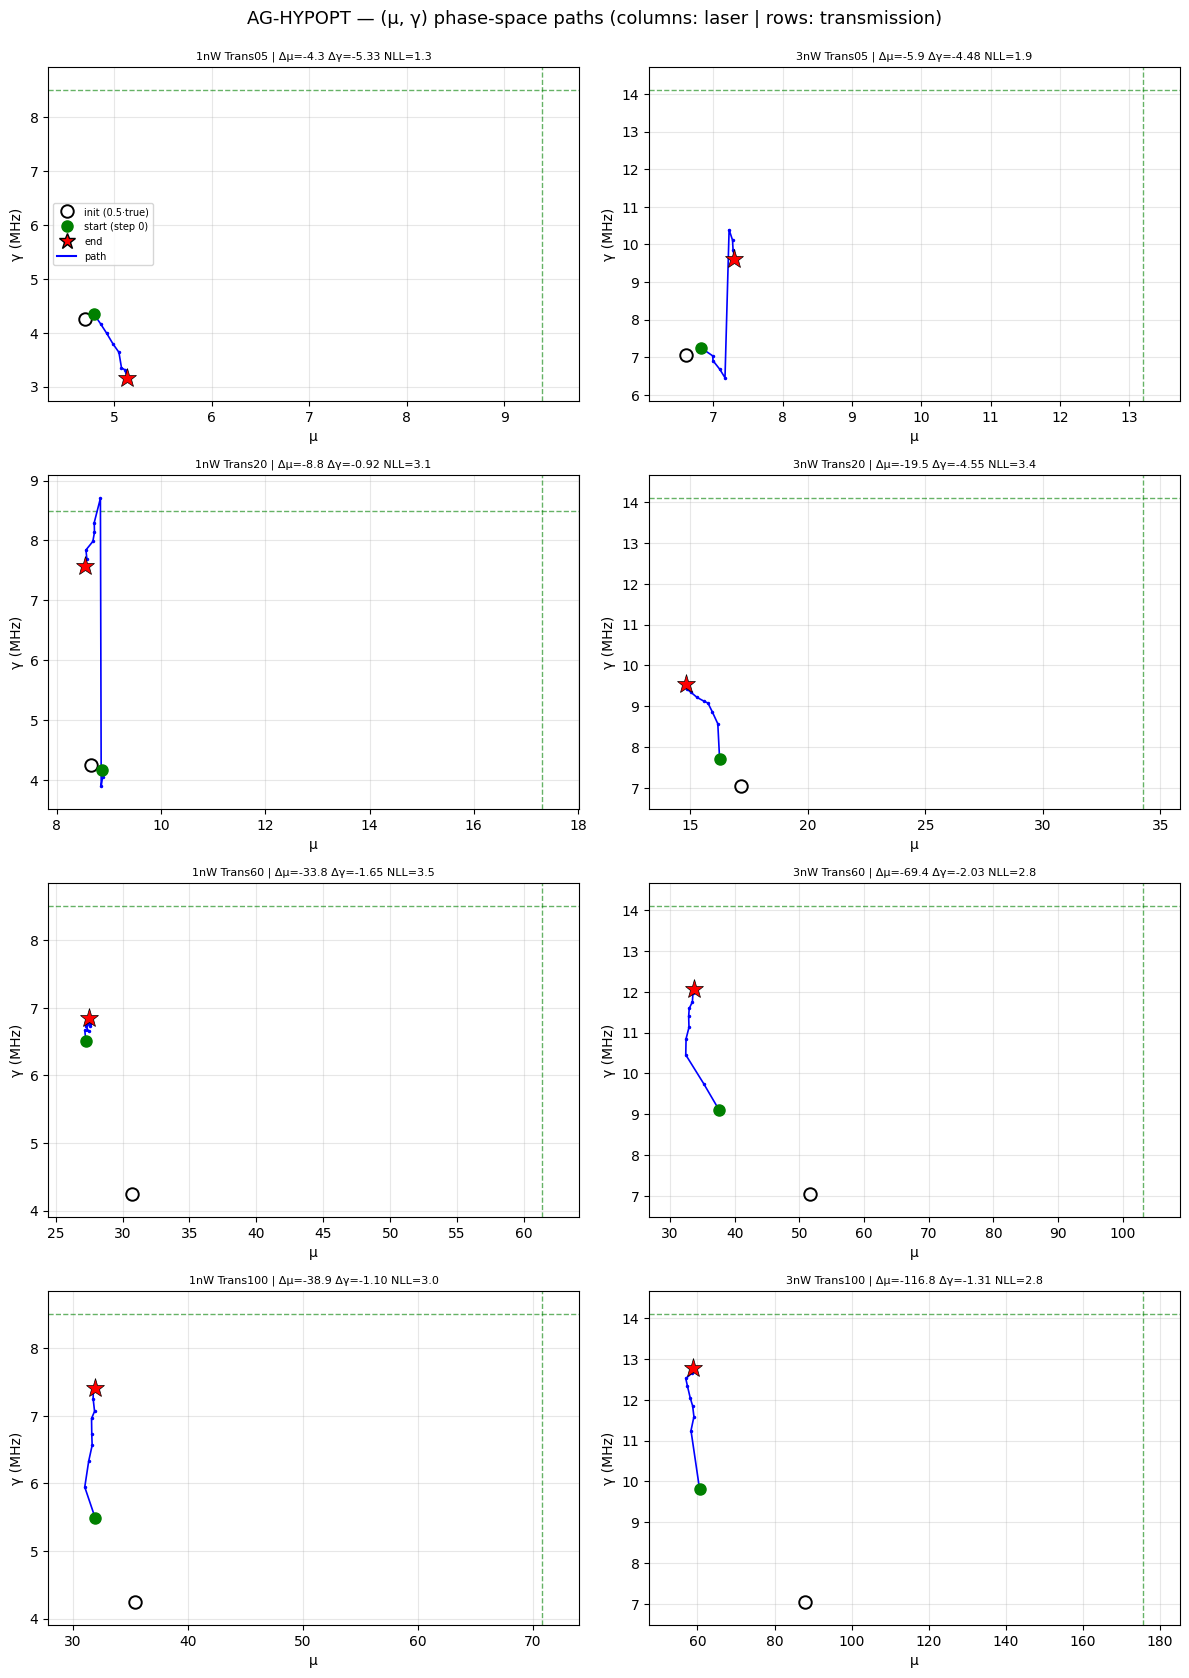

trial finished in 2.4 min
objective = 0.1987 ± 0.0399
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    5.13   -45.4 |     8.50    3.17   -62.8
1nW Trans20    17.32    8.54   -50.7 |     8.50    7.58   -10.8
1nW Trans60    61.37   27.52   -55.2 |     8.50    6.85   -19.4
1nW Trans100   70.82   31.95   -54.9 |     8.50    7.40   -12.9
3nW Trans05    13.20    7.29   -44.8 |    14.10    9.62   -31.8
3nW Trans20    34.28   14.80   -56.8 |    14.10    9.55   -32.3
3nW Trans60   103.20   33.77   -67.3 |    14.10   12.07   -14.4
3nW Trans100  175.71   58.95   -66.4 |    14.10   12.79    -9.3

μ: RMSE 51.984 (rel 55.7%, bias -37.166) | γ: RMSE 3.159 (rel 29.5%, bias -2.671)


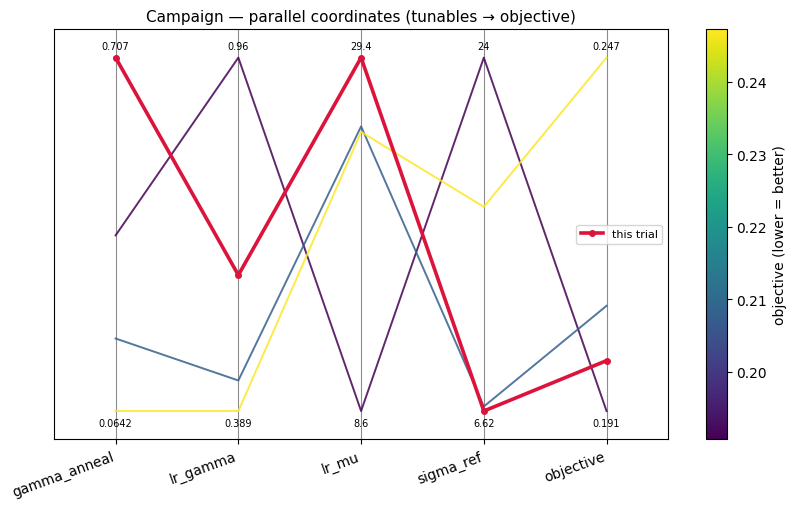

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 04, fourth trial; proposer still in the uniform warm-up phase (3/5), so config is an uninformative random draw: sigma_ref 6.62, lr_mu 29.41, lr_gamma 0.609, gamma_anneal 0.707. Result: objective 0.1987 +/- 0.0399, between trial_01 (0.1907) and trial_02 (0.2075), runtime 2.4 min. mu_fit again sits near half-truth and scatters more at high transmission (Delta-mu% -44.8 to -67.3; 3 nW Trans60/100 -67.3/-66.4), mu RMSE 51.98 (relative 55.7%, bias -37.2) -- similar to trial_02. gamma_fit is the best of the campaign so far: RMSE 3.16 (relative 29.5%), with gamma near-truth at 1 nW Trans20 (-10.8%) and high transmission (1 nW Trans100 -12.9%; 3 nW Trans60/100 -14.4/-9.3%), though Trans05 still degrades (1 nW -62.8%, 3 nW -31.8%). The strong gamma_anneal (0.707) coincides with this improved gamma recovery.

**Summary:** Trial 04 (sigma_ref 6.62, lr_mu 29.41, lr_gamma 0.609, gamma_anneal 0.707) -> objective 0.1987 +/- 0.0399 (between trial_01 and trial_02); mu still ~half-truth, but gamma RMSE is the campaign best (29.5% rel).
**Key insight:** A strong gamma_anneal (0.707) gives the best gamma recovery so far (including rescuing 1 nW Trans20), while the mu attractor remains unchanged -- loss is now mu-dominated.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 04 (sigma_ref 6.62, lr_mu 29.41, lr_gamma 0.609, gamma_anneal 0.707): objective 0.1987 +/- 0.0399 (between trial_01 and trial_02); mu still ~half-truth, gamma RMSE best so far (29.5% rel)'
KEY_INSIGHT = 'A strong gamma_anneal (0.707) yields the campaign-best gamma recovery (rescues 1 nW Trans20), leaving the mu attractor as the dominant loss term.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_04 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_05.ipynb. Open it and follow its cells from the top.
